# SSIM916 — Problem Set #2
# Sentiment Classification of Software Reviews Using Machine Learning

## Notebook Structure

1. Setup & Imports
2. Data Loading & Inspection
3. Preprocessing
4. Train–Test Split
5. Model 1: TF-IDF + Logistic Regression (Baseline)
6. Model 2: DistilBERT (Frozen) + Logistic Regression (Transfer Learning)
7. Model Comparison & Evaluation
8. Analysis & Interpretation
9. Hyperparameter Tuning Results

---

### Data

Pre-processed data and cached embeddings are included in the `data/` folder — no downloads required to reproduce results.

- `data/software_sample.csv` — 12,000 balanced reviews (6,000 negative, 6,000 positive)
- `data/train_embeddings.npy` — cached DistilBERT embeddings for the training set
- `data/test_embeddings.npy` — cached DistilBERT embeddings for the test set

If you want to regenerate from the raw file, download `Software.jsonl` from:  
`https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Software.jsonl`  
and place it in `data/`. Delete the three cached files above and re-run the notebook.

## 1. Setup & Imports

In [1]:
# Standard library
import os
import json
import warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

# HuggingFace Transformers
from transformers import AutoTokenizer, AutoModel
import torch

# Fix random seed at 42 for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Download NLTK resources (cached after first run)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

os.makedirs('data', exist_ok=True)

print('Imports done. Seed = 42.')

Imports done. Seed = 42.


## 2. Data Loading & Inspection

In [2]:
# Load the dataset.
# If software_sample.csv exists (included in repo), load it directly.
# Otherwise, read Software.jsonl line-by-line and build the subsample.
#
# Star rating → label: 1-2 stars = negative (0), 4-5 stars = positive (1), 3 stars dropped.
# Subsample: 6,000 negative + 6,000 positive = 12,000 total, stratified, seed=42.

SAMPLE_CACHE = 'data/software_sample.csv'
RAW_FILE     = 'data/Software.jsonl'

if os.path.exists(SAMPLE_CACHE):
    print('Loading from cache...')
    df = pd.read_csv(SAMPLE_CACHE)
else:
    if not os.path.exists(RAW_FILE):
        raise FileNotFoundError(
            f'Raw data file not found at {RAW_FILE}.\n'
            'Download Software.jsonl from:\n'
            'https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/'
            'resolve/main/raw/review_categories/Software.jsonl\n'
            'and place it in data/.'
        )

    print('Reading Software.jsonl line-by-line (1-2 minutes)...')
    records = []
    with open(RAW_FILE, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            try:
                obj = json.loads(line.strip())
                text   = obj.get('text', '')
                rating = obj.get('rating', None)
                if text and isinstance(text, str) and len(text.strip()) > 10 and rating is not None:
                    records.append({'text': text.strip(), 'rating': float(rating)})
            except (json.JSONDecodeError, KeyError):
                continue
            if (i + 1) % 500000 == 0:
                print(f'  {i+1:,} lines read, {len(records):,} kept...')

    print(f'Total valid reviews: {len(records):,}')
    raw_df = pd.DataFrame(records)

    # Recode ratings to binary labels, drop 3-star
    raw_df['label'] = raw_df['rating'].apply(
        lambda r: 0 if r <= 2 else (1 if r >= 4 else None)
    )
    raw_df = raw_df.dropna(subset=['label'])
    raw_df['label'] = raw_df['label'].astype(int)

    print(f'After dropping 3-star reviews: {len(raw_df):,}')

    # Stratified subsample: 6,000 per class
    n_per_class = 6000
    neg = raw_df[raw_df['label'] == 0].sample(n=n_per_class, random_state=SEED)
    pos = raw_df[raw_df['label'] == 1].sample(n=n_per_class, random_state=SEED)
    df = pd.concat([neg, pos]).sample(frac=1, random_state=SEED).reset_index(drop=True)
    df = df[['text', 'label']]

    df.to_csv(SAMPLE_CACHE, index=False)
    print(f'Saved to {SAMPLE_CACHE}')

print(f'Dataset shape: {df.shape}')
print(df['label'].value_counts())
df.head(3)

Loading from cache...
Dataset shape: (12000, 2)
label
0    6000
1    6000
Name: count, dtype: int64


,text,label
0,What was downloaded?,0
1,This game is good. Would be good for kids.,1
2,Freezes a lot. Can't really fast forward,0


In [3]:
# Basic corpus statistics
df['text_length'] = df['text'].str.split().str.len()

print('=== Corpus Statistics ===')
print(f'Total reviews:        {len(df):,}')
print(f'Negative (label=0):   {(df["label"]==0).sum():,}')
print(f'Positive (label=1):   {(df["label"]==1).sum():,}')
print(f'Mean review length:   {df["text_length"].mean():.1f} tokens')
print(f'Median review length: {df["text_length"].median():.1f} tokens')
print(f'Max review length:    {df["text_length"].max()} tokens')
print(f'Min review length:    {df["text_length"].min()} tokens')

=== Corpus Statistics ===
Total reviews:        12,000
Negative (label=0):   6,000
Positive (label=1):   6,000
Mean review length:   31.9 tokens
Median review length: 20.0 tokens
Max review length:    920 tokens
Min review length:    1 tokens


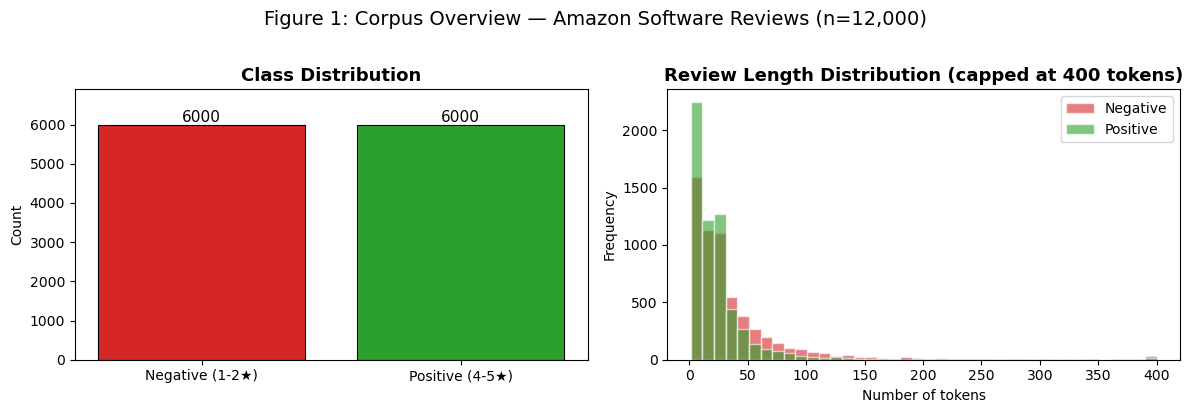

Figure 1 saved.


In [4]:
# ── Figure 1: Corpus overview ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Panel A: class distribution
counts = df['label'].value_counts().sort_index()
axes[0].bar(['Negative (1-2★)', 'Positive (4-5★)'], counts.values,
            color=['#d62728', '#2ca02c'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 60, str(v), ha='center', fontsize=11)

# Panel B: review length by class
for lbl, col, name in [(0, '#d62728', 'Negative'), (1, '#2ca02c', 'Positive')]:
    axes[1].hist(df[df['label']==lbl]['text_length'].clip(upper=400),
                 bins=40, alpha=0.6, color=col, label=name, edgecolor='white')
axes[1].set_title('Review Length Distribution (capped at 400 tokens)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of tokens')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Figure 1: Corpus Overview — Amazon Software Reviews (n=12,000)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/fig1_corpus_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

## 3. Preprocessing

In [5]:
# Text cleaning for TF-IDF: lowercase, remove HTML/URLs, keep letters only,
# remove stopwords, lemmatise.
# Raw text is kept separately for DistilBERT (tokeniser handles its own normalisation).

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)              # remove HTML
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)          # letters only
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print('Cleaning text...')
df['text_clean'] = df['text'].apply(clean_text)

print(f'Original:  {df["text"].iloc[0][:200]}')
print(f'Cleaned:   {df["text_clean"].iloc[0][:200]}')

Cleaning text...
Original:  What was downloaded?
Cleaned:   downloaded


## 4. Train–Test Split

In [6]:
# 80/20 stratified split. Test set is not used until final evaluation.

X_raw   = df['text']        # raw text for DistilBERT
X_clean = df['text_clean']  # cleaned text for TF-IDF
y       = df['label']

(
    X_raw_train, X_raw_test,
    X_clean_train, X_clean_test,
    y_train, y_test
) = train_test_split(
    X_raw, X_clean, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print(f'Training set: {len(y_train):,} rows')
print(f'Test set:     {len(y_test):,} rows')
print(f'Train class balance: {y_train.value_counts().to_dict()}')
print(f'Test class balance:  {y_test.value_counts().to_dict()}')

Training set: 9,600 rows
Test set:     2,400 rows
Train class balance: {0: 4800, 1: 4800}
Test class balance:  {0: 1200, 1: 1200}


## 5. Model 1 — TF-IDF + Logistic Regression (Baseline)

TF-IDF represents each review as a sparse vector of weighted term frequencies. Logistic Regression learns a linear decision boundary over this space and provides interpretable coefficients. The full pipeline is tuned via `RandomizedSearchCV` with `cv=5` stratified folds, directly addressing the main weakness identified in PS1 (manual parameter setting without any search process).

In [7]:
# TF-IDF + Logistic Regression pipeline.
# Using a Pipeline ensures the vectoriser is fitted only on training data
# within each CV fold — no leakage.

tfidf_lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        sublinear_tf=True,       # log-scale term frequencies
        strip_accents='unicode'
    )),
    ('clf', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=SEED
    ))
])

# Search space: tfidf__ prefixes tune the vectoriser, clf__ tunes the classifier
tfidf_lr_param_dist = {
    'tfidf__max_features': [10000, 30000, 50000, 80000],
    'tfidf__ngram_range':  [(1, 1), (1, 2)],
    'tfidf__min_df':       [1, 2, 5],
    'clf__C':              [0.01, 0.1, 1.0, 5.0, 10.0],
}

print('Running RandomizedSearchCV for TF-IDF + LR...')

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

tfidf_lr_search = RandomizedSearchCV(
    estimator=tfidf_lr_pipeline,
    param_distributions=tfidf_lr_param_dist,
    n_iter=20,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
    random_state=SEED,
    verbose=1
)

tfidf_lr_search.fit(X_clean_train, y_train)

print(f'\nBest CV macro F1: {tfidf_lr_search.best_score_:.4f}')
print('Best parameters:')
for k, v in tfidf_lr_search.best_params_.items():
    print(f'  {k}: {v}')

Running RandomizedSearchCV for TF-IDF + LR...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV macro F1: 0.8606
Best parameters:
  tfidf__ngram_range: (1, 2)
  tfidf__min_df: 1
  tfidf__max_features: 10000
  clf__C: 5.0


In [8]:
# ── Evaluate best TF-IDF + LR on held-out test set ───────────────────────────
# Test set has not been seen at any point during training or tuning.

y_pred_tfidf  = tfidf_lr_search.best_estimator_.predict(X_clean_test)
y_proba_tfidf = tfidf_lr_search.best_estimator_.predict_proba(X_clean_test)[:, 1]

acc_tfidf    = accuracy_score(y_test, y_pred_tfidf)
f1_tfidf     = f1_score(y_test, y_pred_tfidf, average='macro')
auc_tfidf    = roc_auc_score(y_test, y_proba_tfidf)
f1_neg_tfidf = f1_score(y_test, y_pred_tfidf, pos_label=0)
f1_pos_tfidf = f1_score(y_test, y_pred_tfidf, pos_label=1)

print('=== TF-IDF + LR (Tuned) — Test Set ===')
print(f'Accuracy:       {acc_tfidf:.4f}')
print(f'Macro F1:       {f1_tfidf:.4f}')
print(f'ROC-AUC:        {auc_tfidf:.4f}')
print(f'F1 (Negative):  {f1_neg_tfidf:.4f}')
print(f'F1 (Positive):  {f1_pos_tfidf:.4f}')
print()
print(classification_report(y_test, y_pred_tfidf,
                             target_names=['Negative', 'Positive']))

=== TF-IDF + LR (Tuned) — Test Set ===
Accuracy:       0.8629
Macro F1:       0.8629
ROC-AUC:        0.9394
F1 (Negative):  0.8641
F1 (Positive):  0.8617

              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86      1200
    Positive       0.87      0.85      0.86      1200

    accuracy                           0.86      2400
   macro avg       0.86      0.86      0.86      2400
weighted avg       0.86      0.86      0.86      2400



## 6. Model 2 — DistilBERT (Frozen) + Logistic Regression (Transfer Learning)

DistilBERT (Sanh et al., 2019) is a distilled version of BERT pre-trained on large English corpora. We use it as a frozen feature extractor: the [CLS] token embedding from the final hidden layer provides a 768-dimensional contextual sentence representation. A Logistic Regression classifier trained on these embeddings constitutes transfer learning — the model's pre-trained linguistic knowledge is applied to our task without modifying its weights. The classifier's regularisation strength is tuned via `RandomizedSearchCV` with `cv=5`.

In [9]:
# Load DistilBERT tokeniser and model (frozen — weights are not updated).
# Weights are downloaded from HuggingFace on first run (~250 MB) and cached locally.
# If you have the cached embeddings in data/, this cell still runs but the model
# is only used if embeddings need to be regenerated.
#
# If you hit an authentication error on first download, run:
#   from huggingface_hub import login; login()
# and paste a Read token from https://huggingface.co/settings/tokens

MODEL_NAME = 'distilbert-base-uncased'
print(f'Loading {MODEL_NAME}...')

tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_model = AutoModel.from_pretrained(MODEL_NAME)
bert_model.eval()  # inference mode only

device = torch.device('cpu')
bert_model = bert_model.to(device)

print(f'Model loaded on: {device}')

Loading distilbert-base-uncased...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cpu


In [10]:
# Extract [CLS] token embeddings from DistilBERT for each review.
# The [CLS] token at position 0 of the final hidden layer gives a fixed-length
# sentence representation (768 dimensions). Reviews longer than 128 subword
# tokens are truncated. Embeddings are cached to disk after first extraction.

def get_bert_embeddings(texts, batch_size=32, max_length=128):
    texts = list(texts)
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i: i + batch_size]
            encoded = tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            ).to(device)
            out = bert_model(**encoded)
            cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()  # [CLS] = position 0
            embeddings.append(cls_emb)
            if (i // batch_size) % 20 == 0:
                print(f'  {min(i+batch_size, len(texts)):,}/{len(texts):,}', end='\r')
    print()
    return np.vstack(embeddings)


TRAIN_EMB = 'data/train_embeddings.npy'
TEST_EMB  = 'data/test_embeddings.npy'

if os.path.exists(TRAIN_EMB) and os.path.exists(TEST_EMB):
    print('Loading cached embeddings...')
    X_train_bert = np.load(TRAIN_EMB)
    X_test_bert  = np.load(TEST_EMB)
else:
    print('Extracting training embeddings (~5-10 min on CPU)...')
    X_train_bert = get_bert_embeddings(X_raw_train)
    np.save(TRAIN_EMB, X_train_bert)

    print('Extracting test embeddings...')
    X_test_bert = get_bert_embeddings(X_raw_test)
    np.save(TEST_EMB, X_test_bert)
    print('Embeddings saved.')

print(f'Train embeddings: {X_train_bert.shape}')
print(f'Test embeddings:  {X_test_bert.shape}')

Extracting training embeddings (~5-10 min on CPU)...
  8,992/9,600
Extracting test embeddings...
  1,952/2,400
Embeddings saved.
Train embeddings: (9600, 768)
Test embeddings:  (2400, 768)


In [11]:
# Standardise embeddings. Scaler is fitted on training data only.
scaler = StandardScaler()
X_train_bert_sc = scaler.fit_transform(X_train_bert)
X_test_bert_sc  = scaler.transform(X_test_bert)
print('Embeddings standardised.')

Embeddings standardised.


In [12]:
# Tune the Logistic Regression classifier on top of fixed DistilBERT embeddings.
# Only C (regularisation strength) is tuned — embeddings are pre-computed.

bert_lr = LogisticRegression(
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED
)

bert_lr_param_dist = {
    'C': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
}

print('Running RandomizedSearchCV for DistilBERT + LR...')

bert_lr_search = RandomizedSearchCV(
    estimator=bert_lr,
    param_distributions=bert_lr_param_dist,
    n_iter=7,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    refit=True,
    random_state=SEED,
    verbose=1
)

bert_lr_search.fit(X_train_bert_sc, y_train)

print(f'\nBest CV macro F1: {bert_lr_search.best_score_:.4f}')
print(f'Best C: {bert_lr_search.best_params_["C"]}')

Running RandomizedSearchCV for DistilBERT + LR...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best CV macro F1: 0.9001
Best C: 0.01


In [13]:
# ── Evaluate best DistilBERT + LR on held-out test set ───────────────────────

y_pred_bert  = bert_lr_search.best_estimator_.predict(X_test_bert_sc)
y_proba_bert = bert_lr_search.best_estimator_.predict_proba(X_test_bert_sc)[:, 1]

acc_bert    = accuracy_score(y_test, y_pred_bert)
f1_bert     = f1_score(y_test, y_pred_bert, average='macro')
auc_bert    = roc_auc_score(y_test, y_proba_bert)
f1_neg_bert = f1_score(y_test, y_pred_bert, pos_label=0)
f1_pos_bert = f1_score(y_test, y_pred_bert, pos_label=1)

print('=== DistilBERT + LR (Tuned) — Test Set ===')
print(f'Accuracy:       {acc_bert:.4f}')
print(f'Macro F1:       {f1_bert:.4f}')
print(f'ROC-AUC:        {auc_bert:.4f}')
print(f'F1 (Negative):  {f1_neg_bert:.4f}')
print(f'F1 (Positive):  {f1_pos_bert:.4f}')
print()
print(classification_report(y_test, y_pred_bert,
                             target_names=['Negative', 'Positive']))

=== DistilBERT + LR (Tuned) — Test Set ===
Accuracy:       0.9058
Macro F1:       0.9058
ROC-AUC:        0.9614
F1 (Negative):  0.9065
F1 (Positive):  0.9051

              precision    recall  f1-score   support

    Negative       0.90      0.91      0.91      1200
    Positive       0.91      0.90      0.91      1200

    accuracy                           0.91      2400
   macro avg       0.91      0.91      0.91      2400
weighted avg       0.91      0.91      0.91      2400



## 7. Model Comparison & Evaluation

In [14]:
# ── Summary comparison table ──────────────────────────────────────────────────

results = pd.DataFrame({
    'Model': ['TF-IDF + LR (Baseline)', 'DistilBERT + LR (Transfer Learning)'],
    'Accuracy':   [round(acc_tfidf, 4),  round(acc_bert, 4)],
    'Macro F1':   [round(f1_tfidf, 4),   round(f1_bert, 4)],
    'ROC-AUC':    [round(auc_tfidf, 4),  round(auc_bert, 4)],
    'F1 (Neg)':   [round(f1_neg_tfidf, 4), round(f1_neg_bert, 4)],
    'F1 (Pos)':   [round(f1_pos_tfidf, 4), round(f1_pos_bert, 4)],
    'Best CV F1': [round(tfidf_lr_search.best_score_, 4),
                   round(bert_lr_search.best_score_, 4)]
})

print('=== Model Comparison Summary ===')
print(results.to_string(index=False))
results.to_csv('data/model_comparison.csv', index=False)

=== Model Comparison Summary ===
                              Model  Accuracy  Macro F1  ROC-AUC  F1 (Neg)  F1 (Pos)  Best CV F1
             TF-IDF + LR (Baseline)    0.8629    0.8629   0.9394    0.8641    0.8617      0.8606
DistilBERT + LR (Transfer Learning)    0.9058    0.9058   0.9614    0.9065    0.9051      0.9001


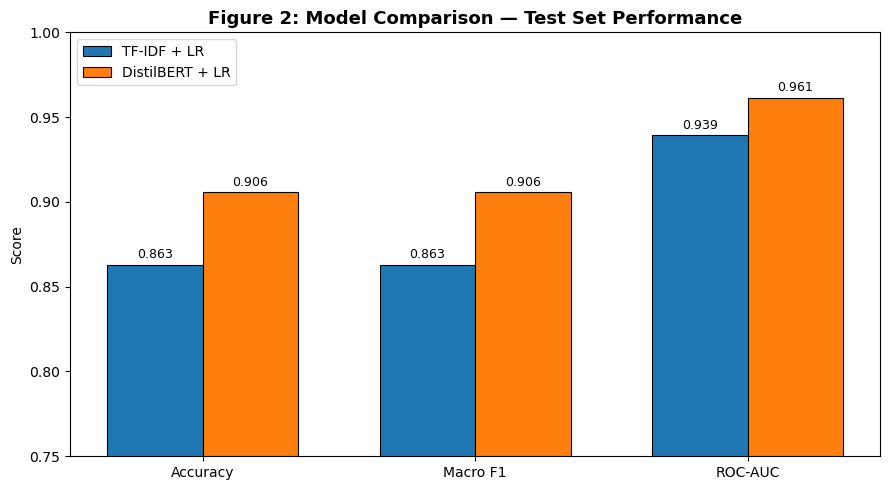

Figure 2 saved.


In [15]:
# ── Figure 2: Metric comparison bar chart ─────────────────────────────────────

metrics     = ['Accuracy', 'Macro F1', 'ROC-AUC']
tfidf_vals  = [acc_tfidf, f1_tfidf, auc_tfidf]
bert_vals   = [acc_bert,  f1_bert,  auc_bert]
x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, tfidf_vals, w, label='TF-IDF + LR',
            color='#1f77b4', edgecolor='black', linewidth=0.8)
b2 = ax.bar(x + w/2, bert_vals,  w, label='DistilBERT + LR',
            color='#ff7f0e', edgecolor='black', linewidth=0.8)

ax.set_ylabel('Score')
ax.set_title('Figure 2: Model Comparison — Test Set Performance',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.75, 1.00)
ax.legend()

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data/fig2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

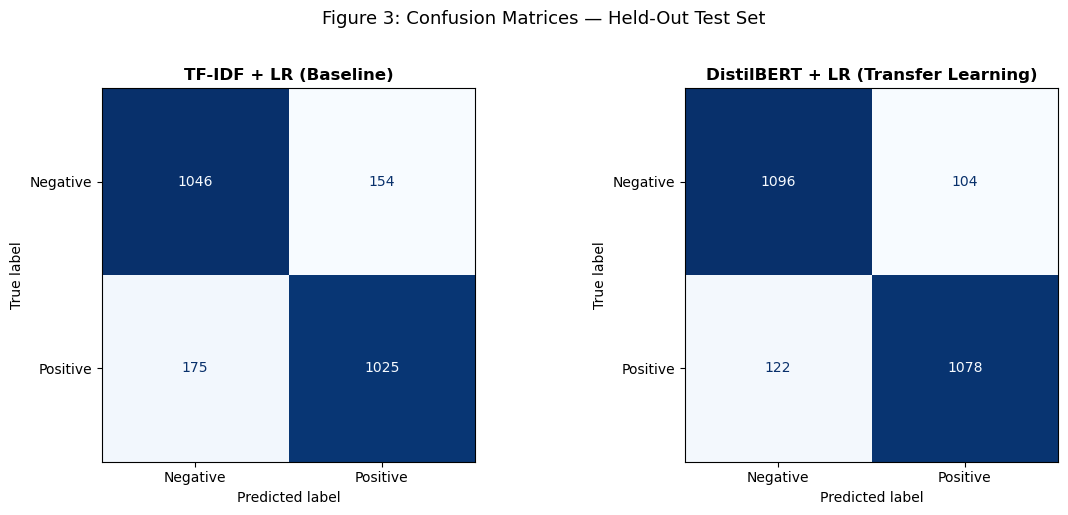

Figure 3 saved.


In [16]:
# ── Figure 3: Confusion matrices ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_tfidf, y_pred_bert],
    ['TF-IDF + LR (Baseline)', 'DistilBERT + LR (Transfer Learning)']
):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('Figure 3: Confusion Matrices — Held-Out Test Set',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/fig3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

## 8. Analysis & Interpretation

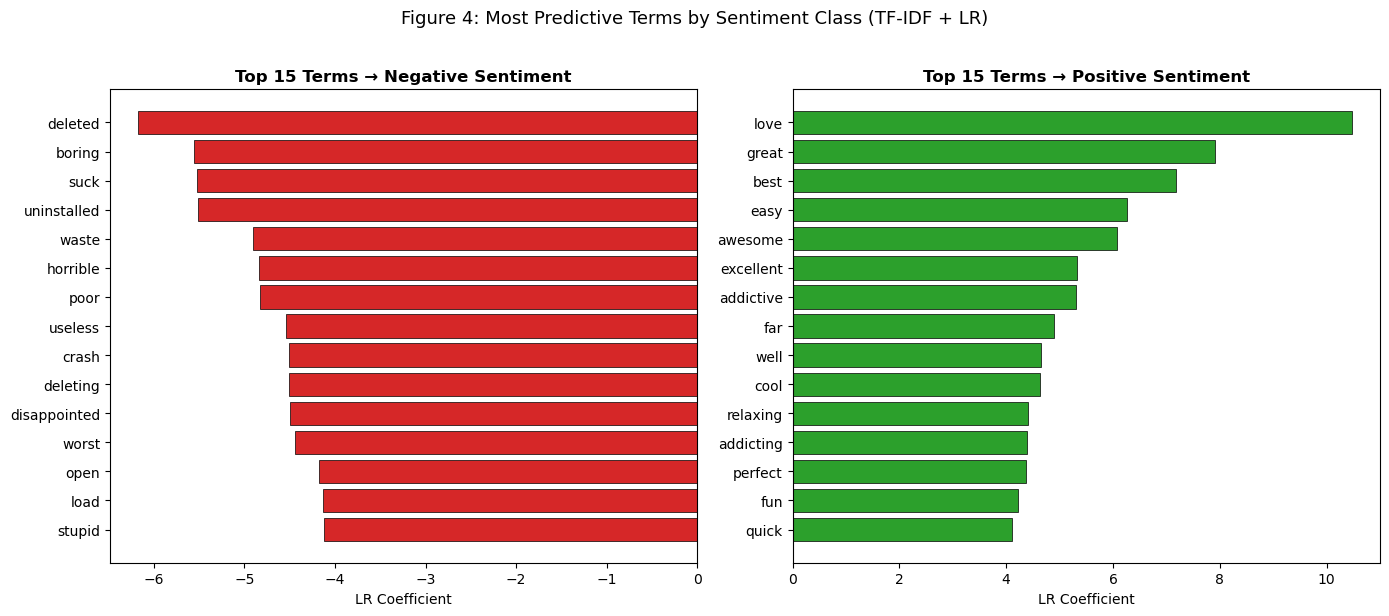

Figure 4 saved.


In [17]:
# ── Figure 4: Top TF-IDF features by class ────────────────────────────────────
# Logistic Regression coefficients indicate which terms most strongly predict
# each sentiment class. This provides interpretable insight into the linguistic
# signals of dissatisfaction in software reviews.

best_tfidf = tfidf_lr_search.best_estimator_
vectorizer = best_tfidf.named_steps['tfidf']
classifier = best_tfidf.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
coefs         = classifier.coef_[0]
N_TOP = 15

top_neg_idx   = np.argsort(coefs)[:N_TOP]
top_pos_idx   = np.argsort(coefs)[-N_TOP:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(range(N_TOP), coefs[top_neg_idx],
             color='#d62728', edgecolor='black', linewidth=0.5)
axes[0].set_yticks(range(N_TOP))
axes[0].set_yticklabels(feature_names[top_neg_idx], fontsize=10)
axes[0].set_title('Top 15 Terms → Negative Sentiment', fontsize=12, fontweight='bold')
axes[0].set_xlabel('LR Coefficient')
axes[0].invert_yaxis()

axes[1].barh(range(N_TOP), coefs[top_pos_idx],
             color='#2ca02c', edgecolor='black', linewidth=0.5)
axes[1].set_yticks(range(N_TOP))
axes[1].set_yticklabels(feature_names[top_pos_idx], fontsize=10)
axes[1].set_title('Top 15 Terms → Positive Sentiment', fontsize=12, fontweight='bold')
axes[1].set_xlabel('LR Coefficient')
axes[1].invert_yaxis()

plt.suptitle('Figure 4: Most Predictive Terms by Sentiment Class (TF-IDF + LR)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/fig4_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

In [18]:
# Error analysis: false negatives (true=negative, predicted=positive).
# In performance marketing, these are the most costly errors — dissatisfied
# customers mispredicted as satisfied may receive the wrong campaign messaging.

test_df = pd.DataFrame({
    'text':       X_raw_test.values,
    'true_label': y_test.values,
    'pred_bert':  y_pred_bert,
    'pred_tfidf': y_pred_tfidf
})

fn_bert  = test_df[(test_df['true_label']==0) & (test_df['pred_bert']==1)]
fn_tfidf = test_df[(test_df['true_label']==0) & (test_df['pred_tfidf']==1)]

print(f'False negatives — TF-IDF + LR:    {len(fn_tfidf)}')
print(f'False negatives — DistilBERT + LR: {len(fn_bert)}')
print('\nSample DistilBERT false negatives:')
for i, row in fn_bert.head(3).iterrows():
    print(f'\n  [{i}] {row["text"][:250]}')
    print(f'       True: Negative | Predicted: Positive')

False negatives — TF-IDF + LR:    154
False negatives — DistilBERT + LR: 104

Sample DistilBERT false negatives:

  [27] Good game!!
       True: Negative | Predicted: Positive

  [57] This is a great fun game after level 100 game stops and freezes all the time needs to be fixed I'm uninstalling
       True: Negative | Predicted: Positive

  [67] Was a brief overview of kings career. Not worth reading. Best to get an actual novel written by Stephen king.
       True: Negative | Predicted: Positive


## 9. Hyperparameter Tuning Results

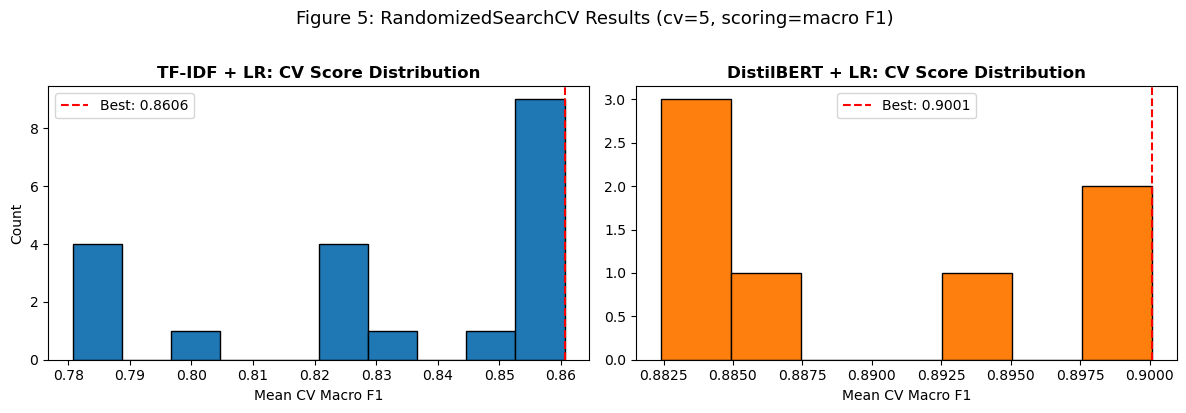

Figure 5 saved.


In [19]:
# ── Figure 5: CV score distributions across search iterations ─────────────────

tfidf_cv = tfidf_lr_search.cv_results_['mean_test_score']
bert_cv  = bert_lr_search.cv_results_['mean_test_score']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tfidf_cv, bins=10, color='#1f77b4', edgecolor='black')
axes[0].axvline(tfidf_lr_search.best_score_, color='red', linestyle='--',
                label=f'Best: {tfidf_lr_search.best_score_:.4f}')
axes[0].set_title('TF-IDF + LR: CV Score Distribution', fontweight='bold')
axes[0].set_xlabel('Mean CV Macro F1')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(bert_cv, bins=7, color='#ff7f0e', edgecolor='black')
axes[1].axvline(bert_lr_search.best_score_, color='red', linestyle='--',
                label=f'Best: {bert_lr_search.best_score_:.4f}')
axes[1].set_title('DistilBERT + LR: CV Score Distribution', fontweight='bold')
axes[1].set_xlabel('Mean CV Macro F1')
axes[1].legend()

plt.suptitle('Figure 5: RandomizedSearchCV Results (cv=5, scoring=macro F1)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/fig5_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

In [20]:
# Final metric summary
print('=' * 60)
print('FINAL METRIC SUMMARY')
print('=' * 60)

print(f'\n--- TF-IDF + LR (Baseline) ---')
print(f'  Best CV Macro F1:  {tfidf_lr_search.best_score_:.4f}')
print(f'  Test Accuracy:     {acc_tfidf:.4f}')
print(f'  Test Macro F1:     {f1_tfidf:.4f}')
print(f'  Test ROC-AUC:      {auc_tfidf:.4f}')
print(f'  Best params:       {tfidf_lr_search.best_params_}')

print(f'\n--- DistilBERT + LR (Transfer Learning) ---')
print(f'  Best CV Macro F1:  {bert_lr_search.best_score_:.4f}')
print(f'  Test Accuracy:     {acc_bert:.4f}')
print(f'  Test Macro F1:     {f1_bert:.4f}')
print(f'  Test ROC-AUC:      {auc_bert:.4f}')
print(f'  Best C:            {bert_lr_search.best_params_["C"]}')

winner = 'DistilBERT + LR' if f1_bert > f1_tfidf else 'TF-IDF + LR'
print(f'\nFinal model: {winner}')
print(f'Macro F1 difference:  {abs(f1_bert - f1_tfidf):.4f}')
print(f'ROC-AUC difference:   {abs(auc_bert - auc_tfidf):.4f}')
print('=' * 60)

FINAL METRIC SUMMARY

--- TF-IDF + LR (Baseline) ---
  Best CV Macro F1:  0.8606
  Test Accuracy:     0.8629
  Test Macro F1:     0.8629
  Test ROC-AUC:      0.9394
  Best params:       {'tfidf__ngram_range': (1, 2), 'tfidf__min_df': 1, 'tfidf__max_features': 10000, 'clf__C': 5.0}

--- DistilBERT + LR (Transfer Learning) ---
  Best CV Macro F1:  0.9001
  Test Accuracy:     0.9058
  Test Macro F1:     0.9058
  Test ROC-AUC:      0.9614
  Best C:            0.01

Final model: DistilBERT + LR
Macro F1 difference:  0.0429
ROC-AUC difference:   0.0220
